# Level 1: Data Overview

## Description:
The objective of this task is to understand the dataset structure, completeness, and basic statistics.

The analysis includes:
- Dataset summary
- Train-wise route details
- Distance and number of stops statistics
- Missing and inconsistent value detection

In [1]:
import pandas as pd

# Upload dataset
from google.colab import files
uploaded = files.upload()

Saving Dataset1.csv to Dataset1 (1).csv


## Load Dataset

The dataset is loaded into a Pandas DataFrame for analysis.

In [3]:
# Load dataset
df = pd.read_csv('Dataset1 (1).csv')
# Display first 5 rows
df.head()

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


# Task 1.1: Dataset Summary

This step shows the total number of records, columns, and basic information about the dataset.

In [4]:
# Total records and columns
print("Total Records:", df.shape[0])
print("Total Columns:", df.shape[1])

# Dataset details
df.info()

Total Records: 186074
Total Columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186074 entries, 0 to 186073
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   SN              186074 non-null  int64 
 1   Train_No        186074 non-null  int64 
 2   Station_Code    186074 non-null  object
 3   1A              186074 non-null  int64 
 4   2A              186074 non-null  int64 
 5   3A              186074 non-null  int64 
 6   SL              186074 non-null  int64 
 7   Station_Name    186074 non-null  object
 8   Route_Number    186074 non-null  int64 
 9   Arrival_time    186074 non-null  object
 10  Departure_Time  186074 non-null  object
 11  Distance        186074 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 17.0+ MB


# Task 1.2: Train-wise Route Start and End Stations

This table displays each train's starting station and ending station.

In [5]:
# Check available columns
df.columns

Index(['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL',
       'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time',
       'Distance'],
      dtype='object')

In [7]:
# Route table
# Group by 'Train_No' and get the first and last 'Station_Name' based on 'SN'
start_stations = df.sort_values(by=['Train_No', 'SN']).groupby('Train_No')['Station_Name'].first().reset_index()
start_stations.rename(columns={'Station_Name': 'Start Station'}, inplace=True)

end_stations = df.sort_values(by=['Train_No', 'SN']).groupby('Train_No')['Station_Name'].last().reset_index()
end_stations.rename(columns={'Station_Name': 'End Station'}, inplace=True)

# Merge the start and end stations
route_table = pd.merge(start_stations, end_stations, on='Train_No')
route_table.rename(columns={'Train_No': 'Train Name'}, inplace=True)

route_table

,Train Name,Start Station,End Station
0,107,SAWANTWADI R,MADGOAN JN.
1,108,MADGOAN JN.,SAWANTWADI R
2,128,MADGOAN JN.,CHHATRAPATI
3,290,DELHI-SAFDAR,DELHI-SAFDAR
4,401,AURANGABAD,VARANASI JN.
...,...,...,...
11108,99904,PUNE JN.,TALEGAON
11109,99905,TALEGAON,SHIVAJINAGAR
11110,99906,PUNE JN.,TALEGAON
11111,99907,TALEGAON,PUNE JN.


# Task 1.3: Basic Statistics

Descriptive statistics are calculated for distance and number of stops to understand the dataset distribution.

In [9]:
# Statistics of distance and stops

# Calculate the number of stops for each train
stops_per_train = df.groupby('Train_No')['SN'].max()

print("Descriptive statistics for Distance (per stop):")
print(df['Distance'].describe())

print("\nDescriptive statistics for Number of Stops (per train):")
print(stops_per_train.describe())

Descriptive statistics for Distance (per stop):
count    186074.000000
mean        281.353838
std         483.743964
min           0.000000
25%          23.000000
50%          73.000000
75%         291.000000
max        4260.000000
Name: Distance, dtype: float64

Descriptive statistics for Number of Stops (per train):
count    11113.000000
mean        16.746963
std         12.995127
min          2.000000
25%          8.000000
50%         15.000000
75%         22.000000
max        118.000000
Name: SN, dtype: float64


# Task 1.4: Missing and Inconsistent Values

Missing values, duplicate records, and unique values are checked to identify data quality issues.

In [10]:
# Missing values
df.isnull().sum()

,0
SN,0
Train_No,0
Station_Code,0
1A,0
2A,0
3A,0
SL,0
Station_Name,0
Route_Number,0
Arrival_time,0


In [11]:
# Duplicate records
df.duplicated().sum()

np.int64(0)

In [12]:
# Unique values check
for col in df.columns:
    print("\nColumn:", col)
    print(df[col].unique()[:10])


Column: SN
[ 1  2  3  4  5  6  7  8  9 10]

Column: Train_No
[107 108 128 290 401 421 422 477 502 504]

Column: Station_Code
['SWV' 'THVM' 'KRMI' 'MAO' 'KUDL' 'SNDD' 'KKW' 'VBW' 'RAJP' 'RN']

Column: 1A
[100 260 345 490 265 355 515 620 670 760]

Column: 2A
[100 228 296 412 232 304 432 516 556 628]

Column: 3A
[100 196 247 334 199 253 349 412 442 496]

Column: SL
[100 164 198 256 166 202 266 308 328 364]

Column: Station_Name
['SAWANTWADI R' 'THIVIM' 'KARMALI' 'MADGOAN JN.' 'KUDAL' 'SINDHU DURG'
 'KANKAVALI' 'VAIBHAVWADI' 'RAJAPUR ROAD' 'RATNAGIRI']

Column: Route_Number
[1]

Column: Arrival_time
['00:00:00' '11:06:00' '11:28:00' '12:10:00' '21:04:00' '21:26:00'
 '22:25:00' '19:40:00' '20:18:00' '20:40:00']

Column: Departure_Time
['10:25:00' '11:08:00' '11:30:00' '00:00:00' '20:30:00' '21:06:00'
 '21:28:00' '19:40:00' '20:20:00' '20:42:00']

Column: Distance
[  0  32  49  78  33  51  83 104 114 132]


# Level 2: Data Cleaning & Feature Engineering

## Description:
In this task, the dataset is cleaned and prepared for further analysis.
Missing values, duplicate records, time formats, and new useful features are handled using Pandas.

## Task 2.1: Missing Values and Duplicate Records

Missing values are identified and handled.
Duplicate records are removed to improve the quality and accuracy of the dataset.

In [14]:
# Check missing values
df.isnull().sum()

,0
SN,0
Train_No,0
Station_Code,0
1A,0
2A,0
3A,0
SL,0
Station_Name,0
Route_Number,0
Arrival_time,0


In [15]:
# Remove duplicate records
df = df.drop_duplicates()
print("Duplicate records removed")
print("Total Records:", df.shape[0])

Duplicate records removed
Total Records: 186074


## Task 2.2: Time Format Standardization

Arrival and departure time columns are converted into a standard datetime format for easier analysis.

In [17]:
# Convert time columns into datetime format

df['Departure_Time'] = pd.to_datetime(
    df['Departure_Time'],
    errors='coerce'
)

df['Arrival_time'] = pd.to_datetime(
    df['Arrival_time'],
    errors='coerce'
)

df[['Departure_Time','Arrival_time']].head()

/tmp/ipykernel_689/362166089.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Departure_Time'] = pd.to_datetime(
/tmp/ipykernel_689/362166089.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_time'] = pd.to_datetime(


,Departure_Time,Arrival_time
0,2026-06-24 10:25:00,2026-06-24 00:00:00
1,2026-06-24 11:08:00,2026-06-24 11:06:00
2,2026-06-24 11:30:00,2026-06-24 11:28:00
3,2026-06-24 00:00:00,2026-06-24 12:10:00
4,2026-06-24 20:30:00,2026-06-24 00:00:00


## Task 2.3: Journey Duration Calculation

A new feature is created to calculate the total travel time taken by each train.

In [21]:
# Calculate journey duration
# If Arrival_time is earlier than Departure_Time, it implies arrival on the next day
mask = df['Arrival_time'] < df['Departure_Time']
df.loc[mask, 'Arrival_time'] = df.loc[mask, 'Arrival_time'] + pd.Timedelta(days=1)

df['Journey Duration'] = df['Arrival_time'] - df['Departure_Time']

df[['Train_No','Journey Duration']].head()

,Train_No,Journey Duration
0,107,0 days 13:35:00
1,107,0 days 23:58:00
2,107,0 days 23:58:00
3,107,0 days 12:10:00
4,108,0 days 03:30:00


## Task 2.4: Feature Creation

Important features such as total distance and number of stops are prepared for analysis.

In [22]:
# Create feature columns
df['Total Distance'] = df['Distance']
# Merge 'stops_per_train' into the main DataFrame
df = df.merge(stops_per_train.rename('Total Stops'), on='Train_No', how='left')

# Display new features
df[['Total Distance','Total Stops']].head()

,Total Distance,Total Stops
0,0,4
1,32,4
2,49,4
3,78,4
4,0,4


# Level 3: Data Exploration

## Description:
In this task, Exploratory Data Analysis (EDA) is performed to identify patterns,
relationships, and meaningful insights from the dataset.

The analysis includes route comparison, station traffic analysis,
and relationship between distance and journey duration.

## Task 3.1: Journey Duration Analysis

The average journey duration is compared across different train routes
to understand which routes take more or less travel time.

In [24]:
# Compare journey duration by route

# Rename 'Train Name' in route_table to 'Train_No' for merging with df
route_table_renamed = route_table.rename(columns={'Train Name': 'Train_No'})

# Merge df with route_table_renamed to add 'Start Station' and 'End Station' to df
df_with_routes = df.merge(route_table_renamed[['Train_No', 'Start Station', 'End Station']],
                          on='Train_No',
                          how='left')

# Now, group by 'Start Station' and 'End Station' and calculate the mean 'Journey Duration'
route_duration = df_with_routes.groupby(
    ['Start Station','End Station']
)['Journey Duration'].mean()
route_duration

Start Station  End Station 
ABHANPUR JN.   RAJIM                    0 days 07:59:40
ABOHAR         JODHPUR JN.              0 days 23:08:14
ABU ROAD       MAHESANA JN    0 days 21:09:28.235294117
ACHHNERA JN.   KASGANJ JN.              0 days 21:18:00
ADILABAD       NANDED         0 days 18:39:06.666666666
                                         ...           
YESVANTPUR J   SHRI MATA VA   0 days 21:43:10.909090909
               SOLAPUR        0 days 21:11:09.230769230
               TATANAGAR JN   0 days 22:27:47.272727272
               VASCO-DA-GAM   0 days 21:03:45.454545454
               VISAKHAPATNA   0 days 21:39:51.428571428
Name: Journey Duration, Length: 4881, dtype: timedelta64[ns]

## Task 3.2: Station Traffic Analysis

The number of trains passing through each station is calculated
to identify high and low traffic stations.

In [26]:
# Starting station traffic
start_station_traffic = df_with_routes['Start Station'].value_counts()
print("Start Station Traffic:")
print(start_station_traffic.head())

# Ending station traffic
end_station_traffic = df_with_routes['End Station'].value_counts()
print("\nEnd Station Traffic:")
print(end_station_traffic.head())

Start Station Traffic:
Start Station
HOWRAH JN.      7977
SEALDAH         7060
CST-MUMBAI      5352
CHENNAI BEAC    3634
KALYAN JN       2975
Name: count, dtype: int64

End Station Traffic:
End Station
HOWRAH JN.    7856
SEALDAH       7066
CST-MUMBAI    5419
KALYAN JN     2667
TAMBARAM      2556
Name: count, dtype: int64


## Task 3.3: Distance and Duration Relationship

Correlation analysis is performed to understand whether distance
has an impact on journey duration.

In [27]:
# Convert duration into minutes

df['Duration Minutes'] = (
    df['Journey Duration'].dt.total_seconds() / 60
)

# Correlation analysis

correlation = df[
    ['Distance','Duration Minutes']
].corr()
correlation

,Distance,Duration Minutes
Distance,1.000000,0.069587
Duration Minutes,0.069587,1.000000


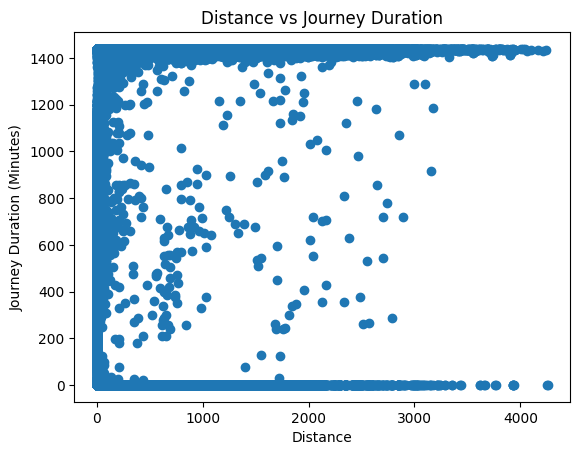

In [28]:
import matplotlib.pyplot as plt

plt.scatter(
    df['Distance'],
    df['Duration Minutes']
)
plt.xlabel("Distance")
plt.ylabel("Journey Duration (Minutes)")
plt.title("Distance vs Journey Duration")
plt.show()

## Task 3.4: Exploratory Insights

Key observations from the analysis:

- Different routes have different average journey durations.
- Some stations have higher train traffic compared to others.
- Distance and journey duration show a relationship where longer routes generally require more travel time.
- These insights help understand train operations and route efficiency.

# Level 4: Visualization & Pattern Analysis

## Description:
In this task, visualizations are created to identify trends, patterns,
and relationships in the dataset.

Matplotlib and Seaborn are used to represent journey duration,
station traffic, and distance relationships.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

## Task 4.1: Journey Duration Across Routes

A bar chart is created to compare the average journey duration
between different train routes.

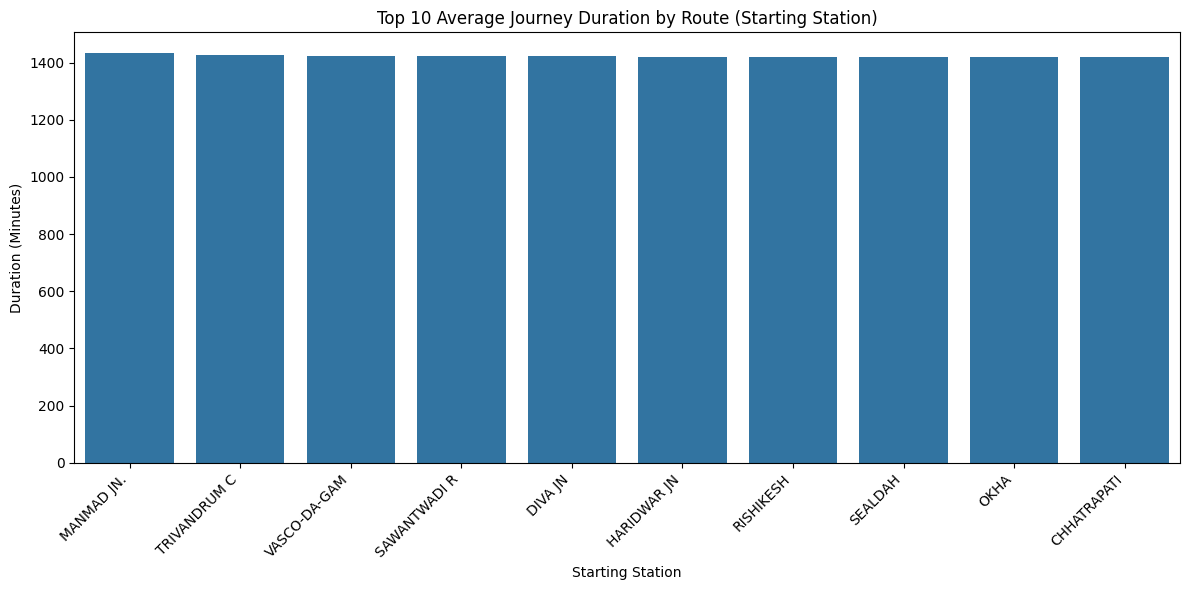

In [31]:
# Calculate average duration by route

# Ensure df_with_routes has 'Duration Minutes' column
# The 'Duration Minutes' column was added to 'df' after 'df_with_routes' was created.
# We need to add 'Duration Minutes' to 'df_with_routes' for this calculation.
if 'Duration Minutes' not in df_with_routes.columns:
    df_with_routes['Duration Minutes'] = df['Duration Minutes']

route_duration_plot = df_with_routes.groupby(
    ['Start Station','End Station']
)['Duration Minutes'].mean().reset_index()

# Sort the data and select the top 10 routes for better visualization
route_duration_plot_sorted = route_duration_plot.sort_values(by='Duration Minutes', ascending=False).head(10)

# Plot chart
plt.figure(figsize=(12,6)) # Increased figure size for better readability

sns.barplot(
    data=route_duration_plot_sorted,
    x='Start Station',
    y='Duration Minutes'
)
plt.title("Top 10 Average Journey Duration by Route (Starting Station)")
plt.xlabel("Starting Station")
plt.ylabel("Duration (Minutes)")
plt.xticks(rotation=45, ha='right') # Rotate and align for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## Task 4.2: Station Traffic Analysis

A count plot is created to identify stations with high and low train traffic.

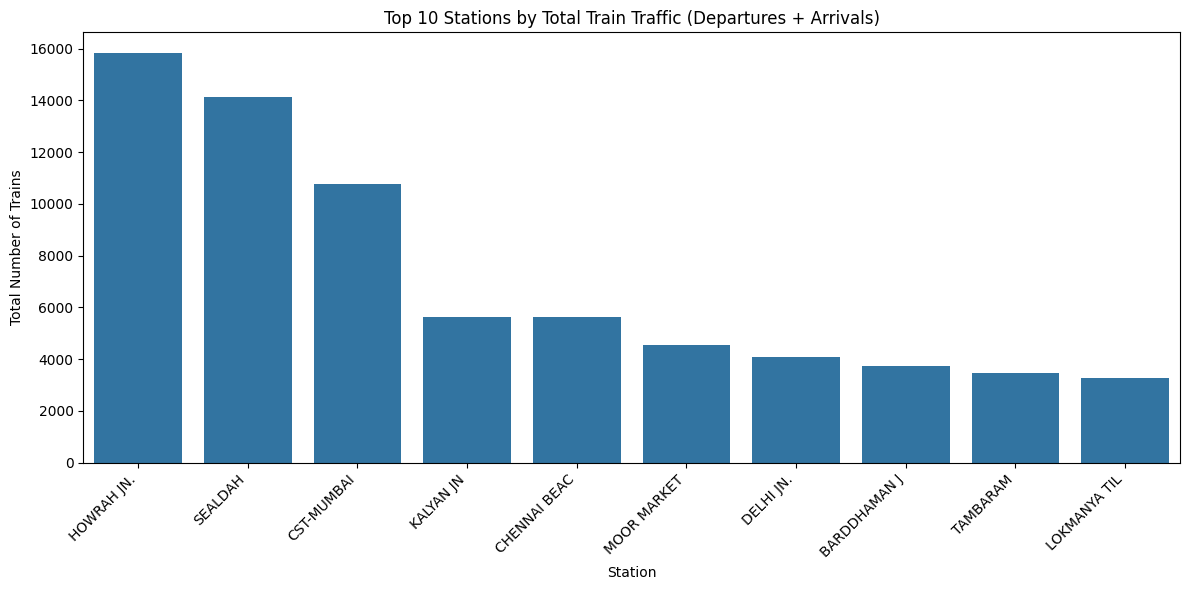

In [33]:
# Calculate total traffic for each station (as start or end)
start_counts = df_with_routes['Start Station'].value_counts()
end_counts = df_with_routes['End Station'].value_counts()

# Combine both series, summing counts for stations that appear in both
total_station_traffic = start_counts.add(end_counts, fill_value=0).sort_values(ascending=False)

# Select top 10 for plotting
top_10_traffic_stations = total_station_traffic.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_traffic_stations.index, y=top_10_traffic_stations.values)
plt.title("Top 10 Stations by Total Train Traffic (Departures + Arrivals)")
plt.xlabel("Station")
plt.ylabel("Total Number of Trains")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Task 4.3: Distance and Journey Duration Relationship

A scatter plot is created to visualize the relationship between
travel distance and journey duration.

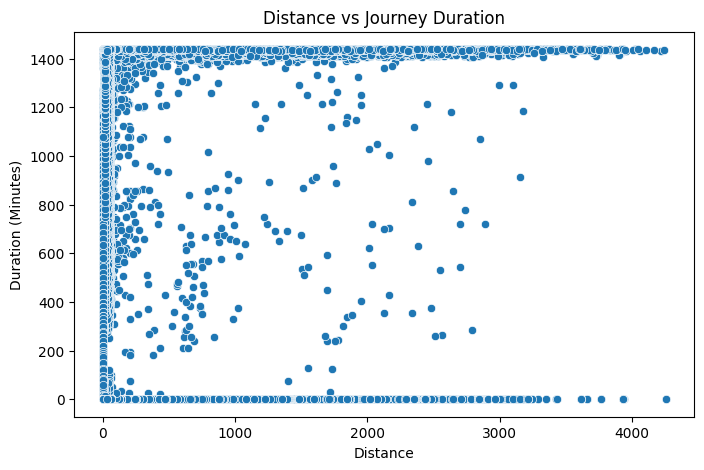

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Distance',
    y='Duration Minutes'
)
plt.title("Distance vs Journey Duration")
plt.xlabel("Distance")
plt.ylabel("Duration (Minutes)")
plt.show()

## Visual Analysis Insights

The visualizations show the following patterns:

- Longer routes generally require more journey time.
- Some stations have higher train traffic compared to others.
- Journey duration varies depending on route distance and stops.
- Visual analysis helps identify operational patterns in train services.

# Level 5: Prediction Model Development

## Description:
In this task, a Machine Learning model is developed to predict train journey duration.

Distance and number of stops are used as input features,
and Linear Regression is applied for prediction.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

## Task 5.1: Feature Selection

Distance and number of stops are selected as features.
Journey duration is used as the target variable for prediction.

In [37]:
X = df[['Distance','Total Stops']]
y = df['Duration Minutes']

# Display dataset
X.head()

,Distance,Total Stops
0,0,4
1,32,4
2,49,4
3,78,4
4,0,4


## Task 5.2: Train-Test Split

The dataset is divided into training and testing data.
Training data is used to build the model and testing data is used for evaluation.

In [38]:
# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (148859, 2)
Testing Data: (37215, 2)


## Task 5.3: Linear Regression Model

A Linear Regression model is trained to predict journey duration
based on distance and number of stops.

In [39]:
# Create model
model = LinearRegression()

# Train model
model.fit(
    X_train,
    y_train
)
print("Model training completed")

Model training completed


In [40]:
# Predict journey duration
y_pred = model.predict(X_test)

# Compare actual and predicted values
results = pd.DataFrame({
    "Actual Duration": y_test,
    "Predicted Duration": y_pred
})
results.head()

,Actual Duration,Predicted Duration
151424,1439.0,1225.164624
121135,1439.0,1315.871407
119814,1438.0,1334.950225
143781,1439.0,1296.731876
157858,1439.0,1272.814835


## Task 5.4: Model Performance Evaluation

MAE and RMSE metrics are calculated to measure prediction accuracy.

Lower values indicate better model performance.

In [41]:
# Calculate MAE

mae = mean_absolute_error(
    y_test,
    y_pred
)

# Calculate RMSE

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Square Error (RMSE):", rmse)

Mean Absolute Error (MAE): 276.7114750104174
Root Mean Square Error (RMSE): 435.176050717171


# Level 6: Final Data Science Project

## Description:
In this final stage, all analysis and machine learning steps are integrated
to create a complete journey time prediction system.

The Linear Regression model is used to predict train journey duration,
and actual values are compared with predicted values using visualization.

## Task 6.1: Journey Duration Prediction System

The trained Linear Regression model is used to predict journey duration.
Actual and predicted journey times are visualized to understand model performance.

In [42]:
# Predict journey duration using trained model
predicted_duration = model.predict(X_test)

# Create comparison dataframe
prediction_result = pd.DataFrame({
    "Actual Duration": y_test,
    "Predicted Duration": predicted_duration
})
prediction_result.head()

,Actual Duration,Predicted Duration
151424,1439.0,1225.164624
121135,1439.0,1315.871407
119814,1438.0,1334.950225
143781,1439.0,1296.731876
157858,1439.0,1272.814835


## Actual vs Predicted Visualization

A graph is created to compare actual journey duration
with the duration predicted by the machine learning model.

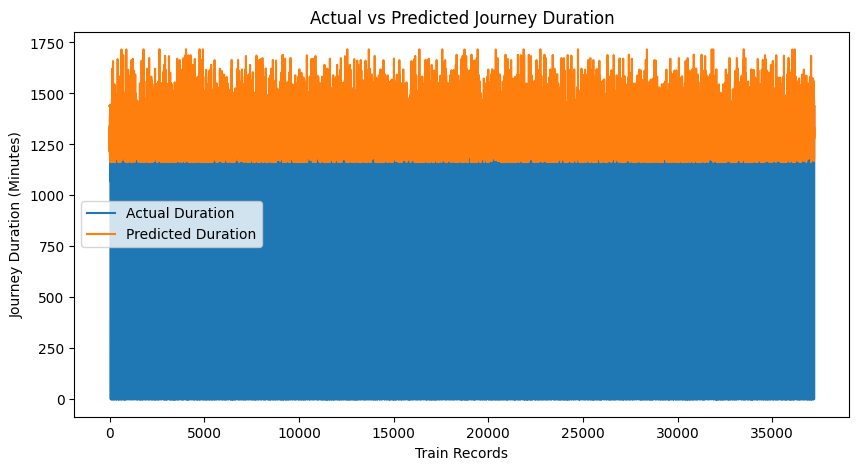

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(
    prediction_result["Actual Duration"].values,
    label="Actual Duration"
)
plt.plot(
    prediction_result["Predicted Duration"].values,
    label="Predicted Duration"
)
plt.title("Actual vs Predicted Journey Duration")
plt.xlabel("Train Records")
plt.ylabel("Journey Duration (Minutes)")
plt.legend()
plt.show()

# Final Conclusion

This project developed an end-to-end train journey duration prediction system.

Steps completed:

- Dataset understanding and inspection
- Data cleaning and preprocessing
- Feature engineering
- Exploratory data analysis
- Data visualization
- Linear Regression model development
- Model evaluation using MAE and RMSE
- Actual vs predicted result visualization


The project demonstrates how Data Science techniques can be used
to analyze train operations and predict journey duration.